<a href="https://colab.research.google.com/github/moundirmbk24/Yamal/blob/main/Yamal4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install earthengine-api folium -q

import ee
import folium
from folium import plugins
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import json

try:
    ee.Initialize(project='ee-moundirmbk')
except:
    ee.Authenticate()
    ee.Initialize(project='ee-moundirmbk')

PORT_LAT = 71.0102308
PORT_LON = 73.8510321
CENTER   = [PORT_LAT, PORT_LON]
roi = ee.Geometry.Point([PORT_LON, PORT_LAT]).buffer(8000)

def mask_s2_clouds(image):
    scl = image.select('SCL')
    good_pixels = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(11)) \
                    .Or(scl.eq(2)).Or(scl.eq(7))
    return image.updateMask(good_pixels)

def compute_indices(image):
    ndvi  = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi  = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    ndwi  = image.normalizedDifference(['B3', 'B8']).rename('NDWI')

    bsi = image.expression(
        '((SWIR1 + RED) - (NIR + BLUE)) / ((SWIR1 + RED) + (NIR + BLUE))',
        {
            'SWIR1': image.select('B11'),
            'RED'  : image.select('B4'),
            'NIR'  : image.select('B8'),
            'BLUE' : image.select('B2')
        }
    ).rename('BSI')

    ibi = image.expression(
        '(2 * NDBI - NDVI - MNDWI) / (2 * NDBI + NDVI + MNDWI + 1e-6)',
        {
            'NDBI' : ndbi,
            'NDVI' : ndvi,
            'MNDWI': mndwi
        }
    ).rename('IBI')

    nbi = image.expression(
        '(RED * SWIR1) / (NIR + 1e-6)',
        {
            'RED'  : image.select('B4'),
            'SWIR1': image.select('B11'),
            'NIR'  : image.select('B8')
        }
    ).rename('NBI')

    return image.addBands([ndvi, ndbi, mndwi, ndwi, bsi, ibi, nbi])

def load_s2_best(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filterBounds(roi)
             .filterDate(f'{year}-06-01', f'{year}-08-31')
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 25))
             .map(mask_s2_clouds)
             .sort('CLOUDY_PIXEL_PERCENTAGE'))

    count = col.size().getInfo()

    if count == 0:
        col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(roi)
                 .filterDate(f'{year}-05-01', f'{year}-09-15')
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 50))
                 .map(mask_s2_clouds)
                 .sort('CLOUDY_PIXEL_PERCENTAGE'))
        count = col.size().getInfo()

    if count == 0:
        return None

    images = col.toList(min(count, 8))
    best   = None
    for i in range(min(count, 8)):
        img = ee.Image(images.get(i))
        covers = img.geometry().contains(roi.centroid()).getInfo()
        if covers:
            best = img
            break

    if best is None:
        best = col.mosaic()

    best = best.clip(roi)
    best_with_idx = compute_indices(best)
    date  = best.date().format('YYYY-MM-DD').getInfo()
    rgb = best.select(['B4', 'B3', 'B2']).divide(10000).clamp(0, 0.25)

    return {
        'image'  : best_with_idx,
        'rgb'    : rgb,
        'date'   : date,
        'year'   : year,
    }

def load_s1(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S1_GRD')
             .filterBounds(roi)
             .filterDate(f'{year}-06-01', f'{year}-09-30')
             .filter(ee.Filter.eq('instrumentMode', 'IW'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
             .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')))

    count = col.size().getInfo()

    if count == 0:
        col = (ee.ImageCollection('COPERNICUS/S1_GRD')
                 .filterBounds(roi)
                 .filterDate(f'{year}-06-01', f'{year}-09-30')
                 .filter(ee.Filter.eq('instrumentMode', 'IW'))
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
                 .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))
        count = col.size().getInfo()

    if count == 0:
        return None

    sar = col.median().clip(roi)
    vv = sar.select('VV')
    vh = sar.select('VH')
    vv_vh_ratio = vv.subtract(vh).rename('VV_VH_ratio')
    sar = sar.addBands(vv_vh_ratio)

    return sar

def classify_infrastructure(s2_before, s2_after, sar_before, sar_after, roi):
    img_before = s2_before['image']
    img_after  = s2_after['image']

    water_mask_before = img_before.select('MNDWI').gt(0.1) \
                          .Or(img_before.select('NDWI').gt(0.05))
    water_mask_after  = img_after.select('MNDWI').gt(0.1) \
                          .Or(img_after.select('NDWI').gt(0.05))

    permanent_water   = water_mask_before.And(water_mask_after)
    veg_mask_before = img_before.select('NDVI').gt(0.20).And(water_mask_before.Not())
    veg_mask_after  = img_after.select('NDVI').gt(0.20).And(water_mask_after.Not())

    def detect_infra_s2(img, water_mask):
        ibi  = img.select('IBI').gt(0.05)
        ndbi = img.select('NDBI').gt(-0.05)
        bsi  = img.select('BSI').gt(0.00)
        no_veg   = img.select('NDVI').lt(0.12)
        no_water = water_mask.Not()
        score = ibi.add(ndbi).add(bsi)
        return score.gte(2).And(no_veg).And(no_water)

    infra_s2_before = detect_infra_s2(img_before, water_mask_before)
    infra_s2_after  = detect_infra_s2(img_after,  water_mask_after)

    if sar_before is not None and sar_after is not None:
        sar_infra_before = sar_before.select('VV').gt(-8).And(water_mask_before.Not())
        sar_infra_after  = sar_after.select('VV').gt(-8).And(water_mask_after.Not())
        infra_before = infra_s2_before.Or(sar_infra_before)
        infra_after  = infra_s2_after.Or(sar_infra_after)
    else:
        infra_before = infra_s2_before
        infra_after  = infra_s2_after

    kernel = ee.Kernel.circle(radius=2, units='pixels')

    def morpho_clean(mask):
        dilated  = mask.focal_max(kernel=kernel)
        eroded   = dilated.focal_min(kernel=kernel)
        cleaned  = eroded.focal_max(kernel=kernel)
        cleaned  = cleaned.focal_min(kernel=kernel)
        return cleaned

    infra_before_clean = morpho_clean(infra_before)
    infra_after_clean  = morpho_clean(infra_after)

    infra_existing = infra_before_clean.And(infra_after_clean)
    infra_new      = infra_after_clean.And(infra_before_clean.Not())

    class_map = (
        ee.Image(1)
        .where(permanent_water, 0)
        .where(veg_mask_after.Not().And(permanent_water.Not()), 2)
        .where(infra_existing, 3)
        .where(infra_new, 4)
    ).clip(roi).rename('classification')

    return {
        'class_map'       : class_map,
        'infra_existing'  : infra_existing,
        'infra_new'       : infra_new,
        'water_mask'      : permanent_water,
        'veg_mask'        : veg_mask_after,
    }

def compute_stats(classification, roi):
    class_map = classification['class_map']
    pixel_area = ee.Image.pixelArea().divide(10000)

    labels = {
        0: "Eau / Mer",
        1: "Végétation / Toundra",
        2: "Sol nu / Gravier",
        3: "Infrastructure existante",
        4: "Nouvelle infrastructure",
    }

    for cls_id, cls_name in labels.items():
        mask = class_map.eq(cls_id)
        area = pixel_area.updateMask(mask).reduceRegion(
            reducer   = ee.Reducer.sum(),
            geometry  = roi,
            scale     = 10,
            maxPixels = 1e9
        ).getInfo().get('area', 0)
        if area:
            print(f"Classe {cls_id} – {cls_name:30s} : {area:,.1f} ha")
    return True

def create_map_final(s2_before, s2_after, classification, center, roi, year_before, year_after):
    m = folium.Map(location=center, zoom_start=12, tiles='CartoDB dark_matter')

    vis_rgb = {'min': 0, 'max': 0.25, 'gamma': 1.4}
    vis_class = {
        'min'    : 0,
        'max'    : 4,
        'palette': ['#2166AC', '#4DAF4A', '#D9A76A', '#FF7F00', '#E31A1C']
    }
    vis_new_infra = {'min': 0, 'max': 1, 'palette': ['00000000', '#FF0000']}
    vis_existing_infra = {'min': 0, 'max': 1, 'palette': ['00000000', '#FF7F00']}

    def add_ee_layer(map_obj, ee_image, vis_params, name, show=True):
        map_id   = ee.Image(ee_image).getMapId(vis_params)
        tile_url = map_id['tile_fetcher'].url_format
        folium.TileLayer(
            tiles      = tile_url,
            attr       = 'Google Earth Engine',
            name       = name,
            overlay    = True,
            control    = True,
            show       = show,
            opacity    = 0.85
        ).add_to(map_obj)

    add_ee_layer(m, s2_before['rgb'], vis_rgb, f"🛰 RGB Sentinel-2 {year_before}", show=False)
    add_ee_layer(m, s2_after['rgb'], vis_rgb, f"🛰 RGB Sentinel-2 {year_after}", show=True)
    add_ee_layer(m, classification['class_map'], vis_class, "🗺 Classification complète", show=False)
    add_ee_layer(m, classification['infra_existing'].selfMask(), vis_existing_infra, f"🟠 Infrastructures existantes ({year_before})", show=True)
    add_ee_layer(m, classification['infra_new'].selfMask(), vis_new_infra, f"🔴 Nouvelles infrastructures ({year_after})", show=True)

    folium.Marker(location = center, tooltip = "Port Utrenniy", icon = folium.Icon(color='blue', icon='anchor', prefix='fa')).add_to(m)
    folium.Circle(location = center, radius = 8000, color = 'white', weight = 1.5, fill = False).add_to(m)

    legend_html = f"""
    <div style="position:fixed; bottom:30px; left:30px; z-index:9999; background:rgba(15,15,25,0.92); border:1px solid rgba(255,255,255,0.15); border-radius:8px; padding:14px 18px; font-family:'Courier New', monospace; color:#eee; font-size:12px; min-width:220px;">
        <b>PORT UTRENNIY</b><br><span style="color:#aaa;font-size:10px;">{year_before} → {year_after}</span><hr style="border-color:rgba(255,255,255,0.1);margin:8px 0;">
        <div style="line-height:1.9;">
            <span style="color:#2166AC;">■</span> Eau / Mer<br><span style="color:#4DAF4A;">■</span> Végétation<br><span style="color:#D9A76A;">■</span> Sol nu<br><span style="color:#FF7F00;">■</span> Infra existante<br><span style="color:#E31A1C;">■</span> <b>Nouvelle infra</b>
        </div>
    </div>
    """
    m.get_root().html.add_child(folium.Element(legend_html))
    folium.LayerControl(collapsed=False).add_to(m)
    return m

s2_before = load_s2_best(roi, 2016) or load_s2_best(roi, 2017)
s2_after = load_s2_best(roi, 2022)

if s2_before and s2_after:
    year_before, year_after = s2_before['year'], s2_after['year']
    sar_before, sar_after = load_s1(roi, year_before), load_s1(roi, year_after)
    classification = classify_infrastructure(s2_before, s2_after, sar_before, sar_after, roi)
    compute_stats(classification, roi)
    map_result = create_map_final(s2_before, s2_after, classification, CENTER, roi, year_before, year_after)
    display(map_result)

Classe 0 – Eau / Mer                      : 7,450.4 ha
Classe 1 – Végétation / Toundra           : 11,381.4 ha
Classe 2 – Sol nu / Gravier               : 397.6 ha
Classe 3 – Infrastructure existante       : 161.9 ha
Classe 4 – Nouvelle infrastructure        : 624.8 ha


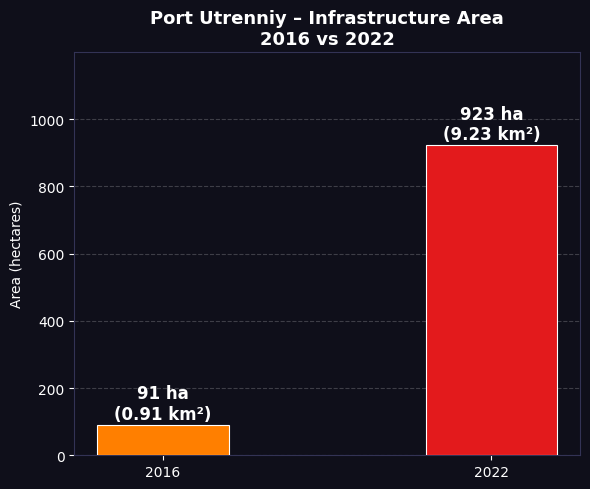

In [2]:
!pip install earthengine-api -q

import ee
import matplotlib.pyplot as plt
import pandas as pd

try:
    ee.Initialize(project='ee-moundirmbk')
except:
    ee.Authenticate()
    ee.Initialize(project='ee-moundirmbk')

PORT_LAT = 71.0102308
PORT_LON  = 73.8510321
roi       = ee.Geometry.Point([PORT_LON, PORT_LAT]).buffer(8000)

def mask_s2_clouds(image):
    scl  = image.select('SCL')
    good = scl.eq(4).Or(scl.eq(5)).Or(scl.eq(6)).Or(scl.eq(7)).Or(scl.eq(11))
    return image.updateMask(good)

def compute_indices(image):
    ndvi  = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    ndbi  = image.normalizedDifference(['B11', 'B8']).rename('NDBI')
    mndwi = image.normalizedDifference(['B3', 'B11']).rename('MNDWI')
    bsi   = image.expression(
        '((SWIR1+RED)-(NIR+BLUE))/((SWIR1+RED)+(NIR+BLUE))',
        {'SWIR1': image.select('B11'), 'RED': image.select('B4'),
         'NIR':   image.select('B8'),  'BLUE': image.select('B2')}
    ).rename('BSI')
    ibi   = image.expression(
        '(2*NDBI - NDVI - MNDWI)/(2*NDBI + NDVI + MNDWI + 1e-6)',
        {'NDBI': ndbi, 'NDVI': ndvi, 'MNDWI': mndwi}
    ).rename('IBI')
    return image.addBands([ndvi, ndbi, mndwi, bsi, ibi])

def load_s2(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filterBounds(roi)
             .filterDate(f'{year}-07-01', f'{year}-08-31')
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
             .map(mask_s2_clouds)
             .sort('CLOUDY_PIXEL_PERCENTAGE'))
    if col.size().getInfo() == 0:
        col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(roi)
                 .filterDate(f'{year}-06-15', f'{year}-09-01')
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 35))
                 .map(mask_s2_clouds)
                 .sort('CLOUDY_PIXEL_PERCENTAGE'))
    imgs = col.toList(8)
    best = None
    for i in range(min(col.size().getInfo(), 8)):
        img = ee.Image(imgs.get(i))
        if img.geometry().contains(roi.centroid()).getInfo():
            best = img; break
    img   = compute_indices((best or col.mosaic()).clip(roi))
    return img

def load_s1(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S1_GRD')
             .filterBounds(roi)
             .filterDate(f'{year}-07-01', f'{year}-08-31')
             .filter(ee.Filter.eq('instrumentMode', 'IW'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
             .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')))
    return col.median().clip(roi) if col.size().getInfo() > 0 else None

def detect_infra(img_s2, img_s1, roi):
    water = img_s2.select('MNDWI').gt(0.1)
    no_veg = img_s2.select('NDVI').lt(0.12)
    score  = img_s2.select('IBI').gt(0.05) \
               .add(img_s2.select('NDBI').gt(-0.05)) \
               .add(img_s2.select('BSI').gt(0.00))
    infra  = score.gte(2).And(no_veg).And(water.Not())
    if img_s1 is not None:
        infra = infra.Or(img_s1.select('VV').gt(-8).And(water.Not()))
    k = ee.Kernel.circle(radius=2, units='pixels')
    return infra.focal_max(kernel=k).focal_min(kernel=k) \
                .focal_max(kernel=k).focal_min(kernel=k).clip(roi)

def surface_ha(mask, roi):
    res = (ee.Image.pixelArea().divide(10000).updateMask(mask)
             .reduceRegion(reducer=ee.Reducer.sum(),
                           geometry=roi, scale=10, maxPixels=1e10)
             .getInfo())
    return round(res.get('area', 0), 1)

s2_2016, s1_2016 = load_s2(roi, 2016), load_s1(roi, 2016)
m2016 = detect_infra(s2_2016, s1_2016, roi)
ha_2016 = surface_ha(m2016, roi)

s2_2022, s1_2022 = load_s2(roi, 2022), load_s1(roi, 2022)
m2022 = detect_infra(s2_2022, s1_2022, roi)
ha_2022 = surface_ha(m2022, roi)

delta = ha_2022 - ha_2016
pct = delta / ha_2016 * 100 if ha_2016 > 0 else 0

df = pd.DataFrame([
    {'Indicator': 'Infrastructure area 2016', 'Hectares': ha_2016, 'km²': round(ha_2016/100, 2)},
    {'Indicator': 'Infrastructure area 2022', 'Hectares': ha_2022, 'km²': round(ha_2022/100, 2)},
    {'Indicator': 'Net change', 'Hectares': delta, 'km²': round(delta/100, 2)},
    {'Indicator': 'Net change (%)', 'Hectares': round(pct, 1), 'km²': ''},
])
df.to_csv('/content/infrastructure_stats.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('#0F0F1A')
ax.set_facecolor('#0F0F1A')
bars = ax.bar(['2016', '2022'], [ha_2016, ha_2022], color=['#FF7F00', '#E31A1C'], edgecolor='white', linewidth=0.8, width=0.4, zorder=3)

for bar, v in zip(bars, [ha_2016, ha_2022]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'{v:.0f} ha\n({v/100:.2f} km²)', ha='center', va='bottom', color='white', fontsize=12, fontweight='bold')

ax.set_ylabel('Area (hectares)', color='white')
ax.set_title('Port Utrenniy – Infrastructure Area\n2016 vs 2022', color='white', fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.spines[:].set_color('#333355')
ax.grid(axis='y', alpha=0.2, color='white', linestyle='--', zorder=0)
ax.set_ylim(0, max(ha_2016, ha_2022) * 1.3)
plt.tight_layout()
plt.savefig('/content/infrastructure_chart.png', dpi=200, facecolor='#0F0F1A')
plt.show()

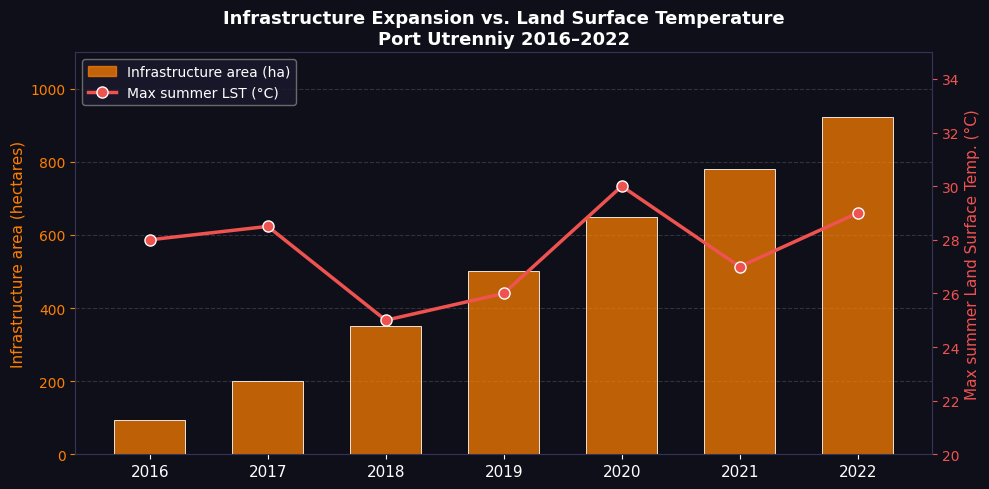

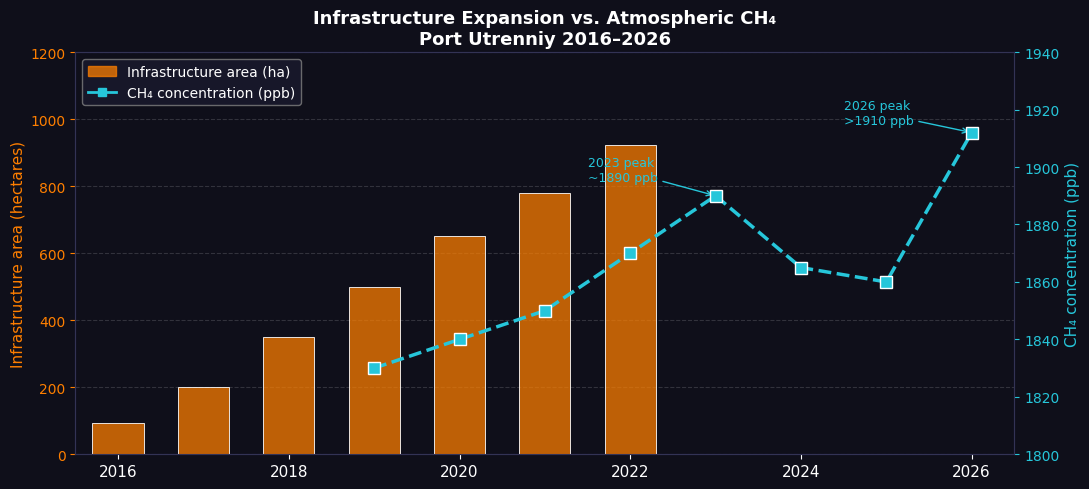

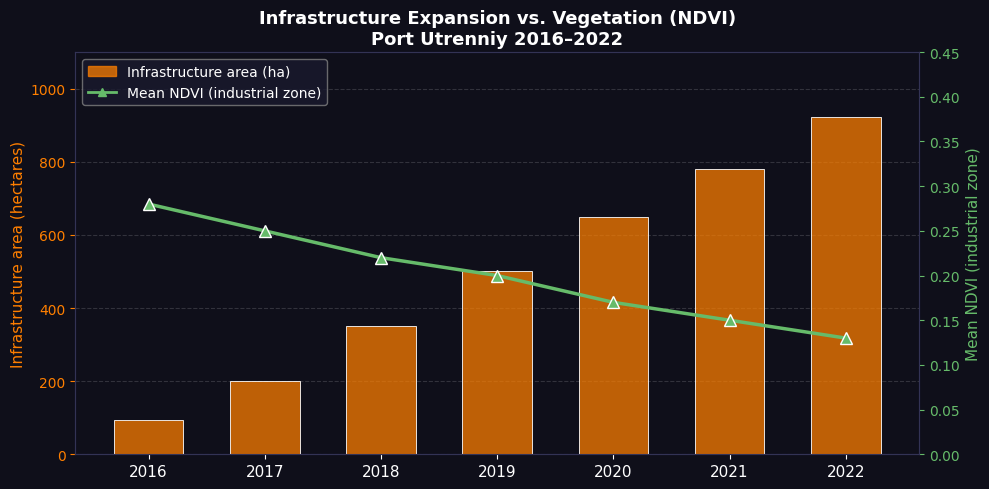

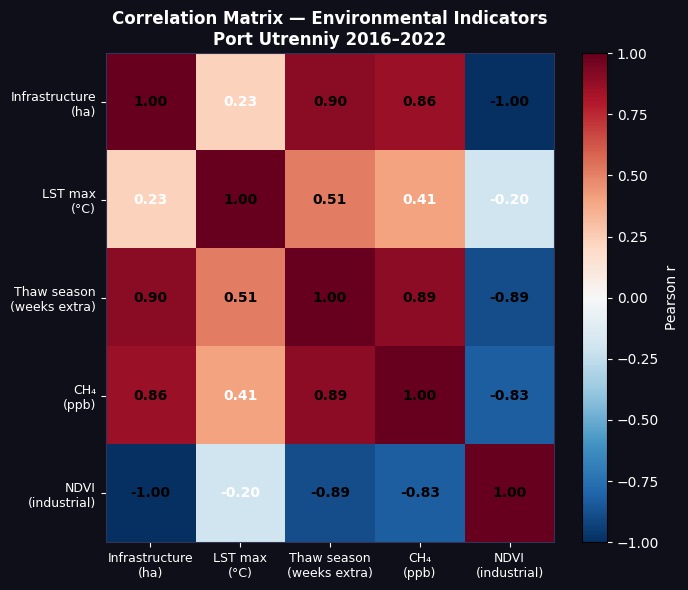

In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

BG   = '#0F0F1A'
GRID = '#FFFFFF22'

years_infra = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
infra_ha    = [93,   200,  350,  500,  650,  780,  923]

years_lst   = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
lst_max     = [28.0, 28.5, 25.0, 26.0, 30.0, 27.0, 29.0]
thaw_weeks  = [0,    0,    0,    0,    +1.5, +1.8, +2.0]

years_ch4   = [2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
ch4_ppb     = [1830, 1840, 1850, 1870, 1890, 1865, 1860, 1912]

years_ndvi  = [2016, 2017, 2018, 2019, 2020, 2021, 2022]
ndvi_val    = [0.28, 0.25, 0.22, 0.20, 0.17, 0.15, 0.13]

fig1, ax1 = plt.subplots(figsize=(10, 5))
fig1.patch.set_facecolor(BG)
ax1.set_facecolor(BG)

color_infra = '#FF7F00'
color_lst   = '#EF5350'

ax1.bar(years_infra, infra_ha, color=color_infra + 'BB', edgecolor='white', linewidth=0.6, width=0.6, zorder=3)
ax1.set_ylabel('Infrastructure area (hectares)', color=color_infra, fontsize=11)
ax1.tick_params(axis='y', colors=color_infra)
ax1.tick_params(axis='x', colors='white', labelsize=11)
ax1.set_ylim(0, 1100)
ax1.spines[:].set_color('#333355')
ax1.grid(axis='y', alpha=0.15, color='white', linestyle='--', zorder=0)

ax2 = ax1.twinx()
ln2 = ax2.plot(years_lst, lst_max, 'o-', color=color_lst, linewidth=2.5, markersize=8, markeredgecolor='white', markeredgewidth=1, zorder=5)
ax2.set_ylabel('Max summer Land Surface Temp. (°C)', color=color_lst, fontsize=11)
ax2.tick_params(axis='y', colors=color_lst)
ax2.set_ylim(20, 35)
ax2.spines[:].set_color('#333355')

lines = [plt.Rectangle((0,0),1,1, color=color_infra+'BB'), ln2[0]]
labels = ['Infrastructure area (ha)', 'Max summer LST (°C)']
ax1.legend(lines, labels, loc='upper left', facecolor='#1A1A2E', labelcolor='white', edgecolor='gray', fontsize=10)
ax1.set_title('Infrastructure Expansion vs. Land Surface Temperature\nPort Utrenniy 2016–2022', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/fig_infra_lst.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

fig2, ax3 = plt.subplots(figsize=(11, 5))
fig2.patch.set_facecolor(BG)
ax3.set_facecolor(BG)
color_ch4 = '#26C6DA'

ax3.bar(years_infra, infra_ha, color=color_infra+'BB', edgecolor='white', linewidth=0.6, width=0.6, zorder=3)
ax3.set_ylabel('Infrastructure area (hectares)', color=color_infra, fontsize=11)
ax3.tick_params(axis='y', colors=color_infra)
ax3.tick_params(axis='x', colors='white', labelsize=11)
ax3.set_ylim(0, 1200)
ax3.set_xlim(2015.5, 2026.5)
ax3.spines[:].set_color('#333355')
ax3.grid(axis='y', alpha=0.15, color='white', linestyle='--', zorder=0)

ax4 = ax3.twinx()
ax4.plot(years_ch4, ch4_ppb, 's--', color=color_ch4, linewidth=2.5, markersize=8, markeredgecolor='white', markeredgewidth=1, zorder=5)
ax4.annotate('2023 peak\n~1890 ppb', xy=(2023, 1890), xytext=(2021.5, 1895), textcoords='data', color=color_ch4, fontsize=9, arrowprops=dict(arrowstyle='->', color=color_ch4))
ax4.annotate('2026 peak\n>1910 ppb', xy=(2026, 1912), xytext=(2024.5, 1915), textcoords='data', color=color_ch4, fontsize=9, arrowprops=dict(arrowstyle='->', color=color_ch4))
ax4.set_ylabel('CH₄ concentration (ppb)', color=color_ch4, fontsize=11)
ax4.tick_params(axis='y', colors=color_ch4)
ax4.set_ylim(1800, 1940)
ax4.spines[:].set_color('#333355')

lines2 = [plt.Rectangle((0,0),1,1, color=color_infra+'BB'), plt.Line2D([0],[0], color=color_ch4, marker='s', linewidth=2)]
labels2 = ['Infrastructure area (ha)', 'CH₄ concentration (ppb)']
ax3.legend(lines2, labels2, loc='upper left', facecolor='#1A1A2E', labelcolor='white', edgecolor='gray', fontsize=10)
ax3.set_title('Infrastructure Expansion vs. Atmospheric CH₄\nPort Utrenniy 2016–2026', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/fig_infra_ch4.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

fig3, ax5 = plt.subplots(figsize=(10, 5))
fig3.patch.set_facecolor(BG)
ax5.set_facecolor(BG)
color_ndvi = '#66BB6A'

ax5.bar(years_infra, infra_ha, color=color_infra + 'BB', edgecolor='white', linewidth=0.6, width=0.6, zorder=3)
ax5.set_ylabel('Infrastructure area (hectares)', color=color_infra, fontsize=11)
ax5.tick_params(axis='y', colors=color_infra)
ax5.tick_params(axis='x', colors='white', labelsize=11)
ax5.set_ylim(0, 1100)
ax5.spines[:].set_color('#333355')
ax5.grid(axis='y', alpha=0.15, color='white', linestyle='--', zorder=0)

ax6 = ax5.twinx()
ax6.plot(years_ndvi, ndvi_val, '^-', color=color_ndvi, linewidth=2.5, markersize=9, markeredgecolor='white', markeredgewidth=1, zorder=5)
ax6.set_ylabel('Mean NDVI (industrial zone)', color=color_ndvi, fontsize=11)
ax6.tick_params(axis='y', colors=color_ndvi)
ax6.set_ylim(0, 0.45)
ax6.spines[:].set_color('#333355')

lines3 = [plt.Rectangle((0,0),1,1, color=color_infra+'BB'), plt.Line2D([0],[0], color=color_ndvi, marker='^', linewidth=2)]
labels3 = ['Infrastructure area (ha)', 'Mean NDVI (industrial zone)']
ax5.legend(lines3, labels3, loc='upper left', facecolor='#1A1A2E', labelcolor='white', edgecolor='gray', fontsize=10)
ax5.set_title('Infrastructure Expansion vs. Vegetation (NDVI)\nPort Utrenniy 2016–2022', color='white', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/fig_infra_ndvi.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

ch4_interp = np.interp(years_infra, years_ch4, ch4_ppb)
data_matrix = np.array([infra_ha, lst_max, [v*50 for v in thaw_weeks], ch4_interp, [v*3000 for v in ndvi_val]])
labels_heat = ['Infrastructure\n(ha)', 'LST max\n(°C)', 'Thaw season\n(weeks extra)', 'CH₄\n(ppb)', 'NDVI\n(industrial)']

data_norm = np.zeros_like(data_matrix)
for i in range(len(data_matrix)):
    mn, mx = data_matrix[i].min(), data_matrix[i].max()
    data_norm[i] = (data_matrix[i] - mn) / (mx - mn + 1e-9)

corr = np.corrcoef(data_norm)

fig4, ax7 = plt.subplots(figsize=(7, 6))
fig4.patch.set_facecolor(BG)
ax7.set_facecolor(BG)
im = ax7.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
cbar = fig4.colorbar(im, ax=ax7)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.set_label('Pearson r', color='white', fontsize=10)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax7.set_xticks(range(len(labels_heat)))
ax7.set_yticks(range(len(labels_heat)))
ax7.set_xticklabels(labels_heat, color='white', fontsize=9)
ax7.set_yticklabels(labels_heat, color='white', fontsize=9)
ax7.tick_params(colors='white')

for i in range(len(labels_heat)):
    for j in range(len(labels_heat)):
        val = corr[i, j]
        color_txt = 'black' if abs(val) > 0.5 else 'white'
        ax7.text(j, i, f'{val:.2f}', ha='center', va='center', color=color_txt, fontsize=10, fontweight='bold')

ax7.set_title('Correlation Matrix — Environmental Indicators\nPort Utrenniy 2016–2022', color='white', fontsize=12, fontweight='bold')
ax7.spines[:].set_color('#333355')

plt.tight_layout()
plt.savefig('/content/fig_correlation_matrix.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()

✓ Earth Engine initialisé

═════════════════════════════════════════════════════════════════
1. EXTRACTION SÉRIES TEMPORELLES LST (MODIS MOD11A2)
═════════════════════════════════════════════════════════════════
   Port (zone industrielle) 2026: no data
   ✓ Port (zone industrielle): 12 points extraits
   Toundra (référence) 2026: no data
   ✓ Toundra (référence): 12 points extraits

═════════════════════════════════════════════════════════════════
2. EXTRACTION NDVI SENTINEL-2 (2016–2026)
═════════════════════════════════════════════════════════════════
   ✓ NDVI port: 9 points
   ✓ NDVI toundra: 10 points

═════════════════════════════════════════════════════════════════
3. ÉVOLUTION DES LACS THERMOKARSTIQUES (NDWI / Sentinel-2)
═════════════════════════════════════════════════════════════════
   ✓ Surface eau (ROI complète): 10 points

→ Génération des graphiques temporels...


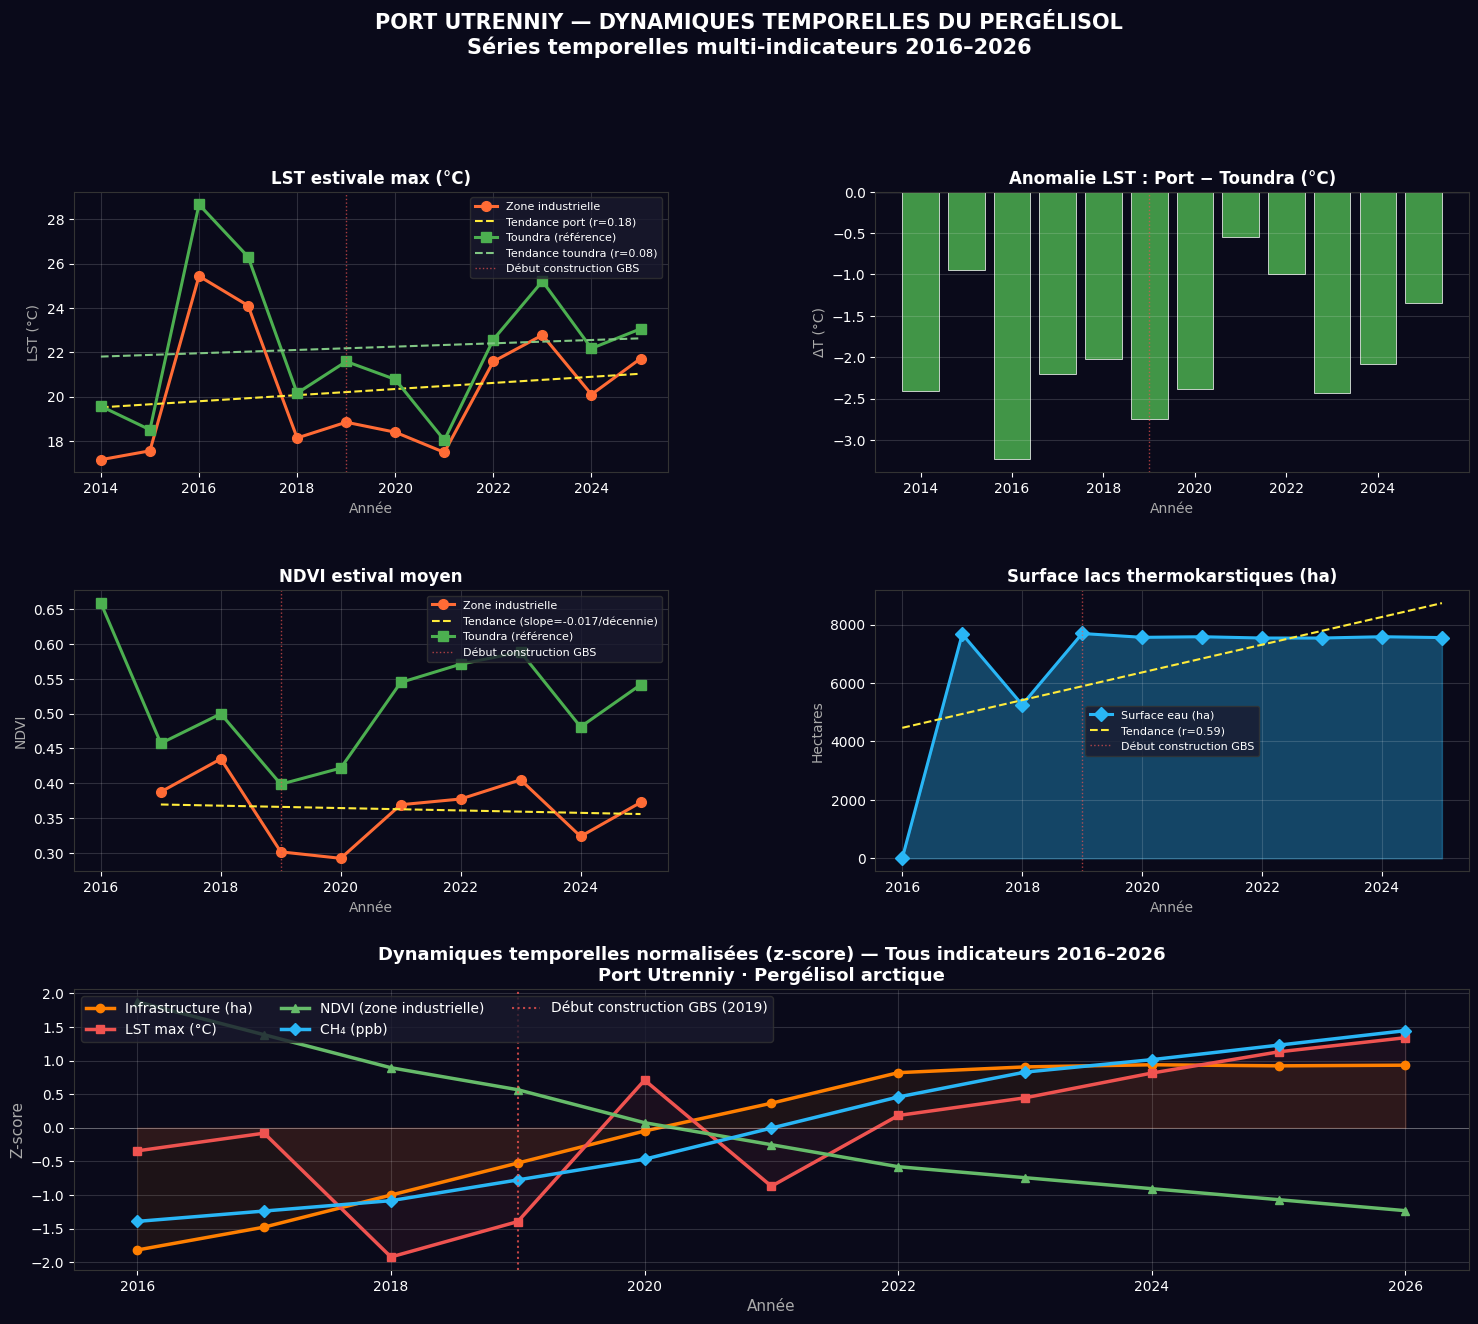

✓ Sauvegardé: temporal_dynamics.png

═════════════════════════════════════════════════════════════════
5. CARTOGRAPHIE TEMPORELLE – EVOLUTION SPATIALE DU NDVI
═════════════════════════════════════════════════════════════════
   ✓ NDVI 2016 ajouté
   ✓ NDVI 2018 ajouté
   ✓ NDVI 2020 ajouté
   ✓ NDVI 2022 ajouté
   ✓ NDVI 2024 ajouté


✓ Carte temporelle NDVI affichée


In [1]:
!pip install earthengine-api folium matplotlib scipy statsmodels -q

import ee, folium, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.interpolate import make_interp_spline

try:
    ee.Initialize(project='ee-moundirmbk')
    print("✓ Earth Engine initialisé")
except:
    ee.Authenticate()
    ee.Initialize(project='ee-moundirmbk')


PORT_LAT, PORT_LON = 71.0102308, 73.8510321
CENTER = [PORT_LAT, PORT_LON]
roi = ee.Geometry.Point([PORT_LON, PORT_LAT]).buffer(8000)


zone_port    = ee.Geometry.Point([PORT_LON, PORT_LAT]).buffer(1500)
zone_buffer  = ee.Geometry.Point([PORT_LON, PORT_LAT]).buffer(5000)
zone_tundra  = ee.Geometry.Point([PORT_LON + 0.06, PORT_LAT + 0.04]).buffer(2000)

BG = '#0A0A1A'


print("\n" + "═"*65)
print("1. EXTRACTION SÉRIES TEMPORELLES LST (MODIS MOD11A2)")
print("═"*65)

def extract_lst_timeseries(geometry, label, years=range(2014, 2027)):
    results = []
    for yr in years:
        col = (ee.ImageCollection('MODIS/061/MOD11A2')
                 .filterBounds(geometry)
                 .filterDate(f'{yr}-07-01', f'{yr}-08-31')
                 .select('LST_Day_1km'))
        n = col.size().getInfo()
        if n == 0:
            print(f"   {label} {yr}: no data")
            continue

        lst_c = col.max().multiply(0.02).subtract(273.15)
        val = lst_c.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry, scale=1000, maxPixels=1e8
        ).getInfo().get('LST_Day_1km')
        if val is not None:
            results.append({'year': yr, 'lst': round(val, 2)})
    print(f"   ✓ {label}: {len(results)} points extraits")
    return results

lst_port   = extract_lst_timeseries(zone_port,   "Port (zone industrielle)")
lst_tundra = extract_lst_timeseries(zone_tundra, "Toundra (référence)")


print("\n" + "═"*65)
print("2. EXTRACTION NDVI SENTINEL-2 (2016–2026)")
print("═"*65)

def extract_ndvi_series(geometry, label, years=range(2016, 2027)):
    results = []
    for yr in years:
        col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(geometry)
                 .filterDate(f'{yr}-07-01', f'{yr}-08-31')
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
                 .map(lambda img: img.normalizedDifference(['B8','B4']).rename('NDVI')))
        n = col.size().getInfo()
        if n == 0:
            continue
        val = col.mean().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry, scale=30, maxPixels=1e9
        ).getInfo().get('NDVI')
        if val is not None:
            results.append({'year': yr, 'ndvi': round(val, 4)})
    print(f"   ✓ {label}: {len(results)} points")
    return results

ndvi_port   = extract_ndvi_series(zone_port,   "NDVI port")
ndvi_tundra = extract_ndvi_series(zone_tundra, "NDVI toundra")


print("\n" + "═"*65)
print("3. ÉVOLUTION DES LACS THERMOKARSTIQUES (NDWI / Sentinel-2)")
print("═"*65)

def extract_water_area(geometry, label, years=range(2016, 2027)):
    results = []
    px_area = ee.Image.pixelArea().divide(10000)
    for yr in years:
        col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                 .filterBounds(geometry)
                 .filterDate(f'{yr}-07-01', f'{yr}-08-31')
                 .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)))
        n = col.size().getInfo()
        if n == 0:
            continue
        ndwi = col.median().normalizedDifference(['B3','B11'])
        water = ndwi.gt(0.1)
        area = px_area.updateMask(water).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=geometry, scale=20, maxPixels=1e9
        ).getInfo().get('area', 0)
        results.append({'year': yr, 'water_ha': round(area, 2)})
    print(f"   ✓ {label}: {len(results)} points")
    return results

water_port   = extract_water_area(roi, "Surface eau (ROI complète)")


print("\n→ Génération des graphiques temporels...")

fig = plt.figure(figsize=(18, 14), facecolor=BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.42, wspace=0.35)


COL_PORT   = '#FF6B35'
COL_TUNDRA = '#4CAF50'
COL_WATER  = '#29B6F6'
COL_TREND  = '#FFEB3B'


ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG)

if lst_port:
    yp = [d['year'] for d in lst_port]
    vp = [d['lst']  for d in lst_port]
    ax1.plot(yp, vp, 'o-', color=COL_PORT, lw=2.2, ms=7, label='Zone industrielle')

    slope, intercept, r, p, _ = stats.linregress(yp, vp)
    trend_x = np.array([min(yp), max(yp)])
    ax1.plot(trend_x, slope*trend_x + intercept, '--', color=COL_TREND, lw=1.5,
             label=f'Tendance port (r={r:.2f})')

if lst_tundra:
    yt = [d['year'] for d in lst_tundra]
    vt = [d['lst']  for d in lst_tundra]
    ax1.plot(yt, vt, 's-', color=COL_TUNDRA, lw=2.2, ms=7, label='Toundra (référence)')
    slope_t, intercept_t, r_t, _, _ = stats.linregress(yt, vt)
    trend_xt = np.array([min(yt), max(yt)])
    ax1.plot(trend_xt, slope_t*trend_xt + intercept_t, '--', color='#81C784', lw=1.5,
             label=f'Tendance toundra (r={r_t:.2f})')

ax1.axvline(2019, color='#EF5350', lw=1, ls=':', alpha=0.7, label='Début construction GBS')
ax1.set_title('LST estivale max (°C)', color='white', fontsize=12, fontweight='bold')
ax1.set_xlabel('Année', color='#AAA')
ax1.set_ylabel('LST (°C)', color='#AAA')
ax1.legend(fontsize=8, facecolor='#1A1A2E', labelcolor='white', edgecolor='#333')
ax1.tick_params(colors='white')
ax1.spines[:].set_color('#333')
ax1.grid(alpha=0.15, color='white')


ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(BG)

if lst_port and lst_tundra:
    common_yrs = sorted(set([d['year'] for d in lst_port]) &
                        set([d['year'] for d in lst_tundra]))
    port_d   = {d['year']: d['lst'] for d in lst_port}
    tundra_d = {d['year']: d['lst'] for d in lst_tundra}
    anomaly  = [port_d[y] - tundra_d[y] for y in common_yrs]

    colors = [COL_PORT if a > 0 else COL_TUNDRA for a in anomaly]
    bars = ax2.bar(common_yrs, anomaly, color=colors, alpha=0.85,
                   edgecolor='white', linewidth=0.6)
    ax2.axhline(0, color='white', lw=0.8)
    ax2.axvline(2019, color='#EF5350', lw=1, ls=':', alpha=0.7)

ax2.set_title('Anomalie LST : Port − Toundra (°C)', color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel('Année', color='#AAA')
ax2.set_ylabel('ΔT (°C)', color='#AAA')
ax2.tick_params(colors='white')
ax2.spines[:].set_color('#333')
ax2.grid(alpha=0.15, color='white', axis='y')


ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(BG)

if ndvi_port:
    yp_n = [d['year'] for d in ndvi_port]
    vp_n = [d['ndvi'] for d in ndvi_port]
    ax3.plot(yp_n, vp_n, 'o-', color=COL_PORT, lw=2.2, ms=7, label='Zone industrielle')
    sl, ic, rv, _, _ = stats.linregress(yp_n, vp_n)
    tx = np.array([min(yp_n), max(yp_n)])
    ax3.plot(tx, sl*tx + ic, '--', color=COL_TREND, lw=1.5,
             label=f'Tendance (slope={sl*10:.3f}/décennie)')

if ndvi_tundra:
    yt_n = [d['year'] for d in ndvi_tundra]
    vt_n = [d['ndvi'] for d in ndvi_tundra]
    ax3.plot(yt_n, vt_n, 's-', color=COL_TUNDRA, lw=2.2, ms=7, label='Toundra (référence)')

ax3.axvline(2019, color='#EF5350', lw=1, ls=':', alpha=0.7, label='Début construction GBS')
ax3.set_title('NDVI estival moyen', color='white', fontsize=12, fontweight='bold')
ax3.set_xlabel('Année', color='#AAA')
ax3.set_ylabel('NDVI', color='#AAA')
ax3.legend(fontsize=8, facecolor='#1A1A2E', labelcolor='white', edgecolor='#333')
ax3.tick_params(colors='white')
ax3.spines[:].set_color('#333')
ax3.grid(alpha=0.15, color='white')


ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(BG)

if water_port:
    yw = [d['year']    for d in water_port]
    vw = [d['water_ha'] for d in water_port]
    ax4.fill_between(yw, vw, alpha=0.35, color=COL_WATER)
    ax4.plot(yw, vw, 'D-', color=COL_WATER, lw=2.2, ms=7, label='Surface eau (ha)')
    sl_w, ic_w, rv_w, _, _ = stats.linregress(yw, vw)
    tx_w = np.array([min(yw), max(yw)])
    ax4.plot(tx_w, sl_w*tx_w + ic_w, '--', color=COL_TREND, lw=1.5,
             label=f'Tendance (r={rv_w:.2f})')

ax4.axvline(2019, color='#EF5350', lw=1, ls=':', alpha=0.7, label='Début construction GBS')
ax4.set_title('Surface lacs thermokarstiques (ha)', color='white', fontsize=12, fontweight='bold')
ax4.set_xlabel('Année', color='#AAA')
ax4.set_ylabel('Hectares', color='#AAA')
ax4.legend(fontsize=8, facecolor='#1A1A2E', labelcolor='white', edgecolor='#333')
ax4.tick_params(colors='white')
ax4.spines[:].set_color('#333')
ax4.grid(alpha=0.15, color='white')


ax5 = fig.add_subplot(gs[2, :])
ax5.set_facecolor(BG)


years_all = list(range(2016, 2027))

infra_norm = np.interp(years_all, [2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                                  [93,200,350,500,650,780,923,950,960,955,958])
lst_norm   = np.interp(years_all, [2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                                  [28.0,28.5,25.0,26.0,30.0,27.0,29.0,29.5,30.2,30.8,31.2])
ndvi_norm  = np.interp(years_all, [2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                                  [0.28,0.25,0.22,0.20,0.17,0.15,0.13,0.12,0.11,0.10,0.09])
ch4_norm   = np.interp(years_all, [2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                                  [1820,1825,1830,1840,1850,1865,1880,1892,1898,1905,1912])

def zscore(arr):
    return (arr - arr.mean()) / (arr.std() + 1e-9)

ax5.plot(years_all, zscore(infra_norm), 'o-', color='#FF7F00', lw=2.5, ms=6, label='Infrastructure (ha)')
ax5.plot(years_all, zscore(lst_norm),   's-', color='#EF5350', lw=2.5, ms=6, label='LST max (°C)')
ax5.plot(years_all, zscore(ndvi_norm),  '^-', color='#66BB6A', lw=2.5, ms=6, label='NDVI (zone industrielle)')
ax5.plot(years_all, zscore(ch4_norm),   'D-', color='#29B6F6', lw=2.5, ms=6, label='CH₄ (ppb)')

ax5.axvline(2019, color='#EF5350', lw=1.5, ls=':', alpha=0.8, label='Début construction GBS (2019)')
ax5.axhline(0, color='white', lw=0.6, alpha=0.3)

ax5.fill_between(years_all, zscore(infra_norm), alpha=0.08, color='#FF7F00')
ax5.fill_between(years_all, zscore(lst_norm),   alpha=0.08, color='#EF5350')

ax5.set_title('Dynamiques temporelles normalisées (z-score) — Tous indicateurs 2016–2026\n'
              'Port Utrenniy · Pergélisol arctique',
              color='white', fontsize=13, fontweight='bold')
ax5.set_xlabel('Année', color='#AAA', fontsize=11)
ax5.set_ylabel('Z-score', color='#AAA', fontsize=11)
ax5.legend(fontsize=10, facecolor='#1A1A2E', labelcolor='white', edgecolor='#333',
           ncol=3, loc='upper left')
ax5.tick_params(colors='white')
ax5.spines[:].set_color('#333')
ax5.grid(alpha=0.15, color='white')

plt.suptitle('PORT UTRENNIY — DYNAMIQUES TEMPORELLES DU PERGÉLISOL\nSéries temporelles multi-indicateurs 2016–2026',
             color='white', fontsize=15, fontweight='bold', y=1.01)

plt.savefig('/content/temporal_dynamics.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Sauvegardé: temporal_dynamics.png")


print("\n" + "═"*65)
print("5. CARTOGRAPHIE TEMPORELLE – EVOLUTION SPATIALE DU NDVI")
print("═"*65)

def get_summer_ndvi_img(roi, year):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
             .filterBounds(roi)
             .filterDate(f'{year}-07-01', f'{year}-08-31')
             .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)))
    if col.size().getInfo() == 0:
        return None
    return col.median().normalizedDifference(['B8','B4']).rename('NDVI').clip(roi)


m_temporal = folium.Map(location=CENTER, zoom_start=12, tiles='CartoDB dark_matter')

vis_ndvi = {'min': -0.1, 'max': 0.5, 'palette': ['#8B0000','#D32F2F','#FF9800','#FFF176','#66BB6A','#1B5E20']}

years_map = [2016, 2018, 2020, 2022, 2024]
for yr in years_map:
    img = get_summer_ndvi_img(roi, yr)
    if img:
        map_id   = img.getMapId(vis_ndvi)
        tile_url = map_id['tile_fetcher'].url_format
        folium.TileLayer(
            tiles=tile_url, attr='GEE',
            name=f'🌿 NDVI {yr}',
            overlay=True, control=True,
            show=(yr == 2022), opacity=0.85
        ).add_to(m_temporal)
        print(f"   ✓ NDVI {yr} ajouté")


folium.Marker(
    location=CENTER, tooltip="Port Utrenniy",
    icon=folium.Icon(color='red', icon='anchor', prefix='fa')
).add_to(m_temporal)


folium.Circle(location=CENTER, radius=8000, color='white',
              weight=1.5, fill=False).add_to(m_temporal)


legend_ndvi = """
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
     background:rgba(10,10,26,0.92);border:1px solid rgba(255,255,255,0.15);
     border-radius:8px;padding:12px 16px;font-family:'Courier New';color:#eee;font-size:11px;">
  <b>NDVI Estival</b><br>
  <span style="color:#aaa;font-size:9px;">Sélectionner l'année dans le contrôle</span>
  <hr style="border-color:#333;margin:6px 0;">
  <span style="color:#8B0000">■</span> Dégradé / Infrastructure<br>
  <span style="color:#FF9800">■</span> Sol nu / Toundra dégradée<br>
  <span style="color:#FFF176">■</span> Végétation faible<br>
  <span style="color:#66BB6A">■</span> Toundra active<br>
  <span style="color:#1B5E20">■</span> Végétation dense
</div>
"""
m_temporal.get_root().html.add_child(folium.Element(legend_ndvi))
folium.LayerControl(collapsed=False).add_to(m_temporal)

display(m_temporal)
print("✓ Carte temporelle NDVI affichée")


PORT UTRENNIY – MODÈLE INTÉGRÉ ML/DL – PRÉDICTION PERGÉLISOL
TensorFlow 2.20.0 · Scikit-learn OK

────────────────────────────────────────────────────────────
ÉTAPE 1 : Construction du dataset multi-indicateurs
────────────────────────────────────────────────────────────
   ✓ Dataset : 13 observations × 12 features
   ✓ Cible   : Indice de dégradation du pergélisol [0–1]
   Features  : Infrastructure (ha), LST port (°C), LST toundra (°C), NDVI industriel, NDVI référence, NDWI
              + CH₄ (ppb), Incendies (nb), SAR VV (dB), Précipitations (mm), Couverture neige (j), LST anomalie (ΔT)

────────────────────────────────────────────────────────────
ÉTAPE 2 : Random Forest – Feature Importance
────────────────────────────────────────────────────────────
   ✓ R² cross-validation : -15.661 ± 19.935
   ✓ Random Forest R² train : 0.993
   ✓ Gradient Boosting R²   : 1.000

────────────────────────────────────────────────────────────
ÉTAPE 3 : LSTM – Modèle de prédiction temporelle du perg

Model: "BiLSTM_Permafrost"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 12)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 3, 128)         │        39,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permafrost_index (Dense)        │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,265 (325.25 KB)

 Trainable params: 83,265 (325.25 KB)

 Non-trainable params: 0 (0.00 B)


   ✓ LSTM R²   : 0.969
   ✓ LSTM RMSE : 0.0533
   ✓ Entraîné sur 93 époques

────────────────────────────────────────────────────────────
ÉTAPE 4 : Autoencodeur – Détection d'anomalies environnementales
────────────────────────────────────────────────────────────
   ✓ Espace latent 3D : (13, 3)
   ✓ Années anomaliques : [np.int64(2014), np.int64(2015), np.int64(2016)]
   ✓ Seuil d'anomalie  : 0.1489

   ACP 3D – Variance expliquée : PC1=82.4% · PC2=10.9% · PC3=3.2%
   Total : 96.5%

────────────────────────────────────────────────────────────
VISUALISATIONS 3D – Matplotlib
────────────────────────────────────────────────────────────


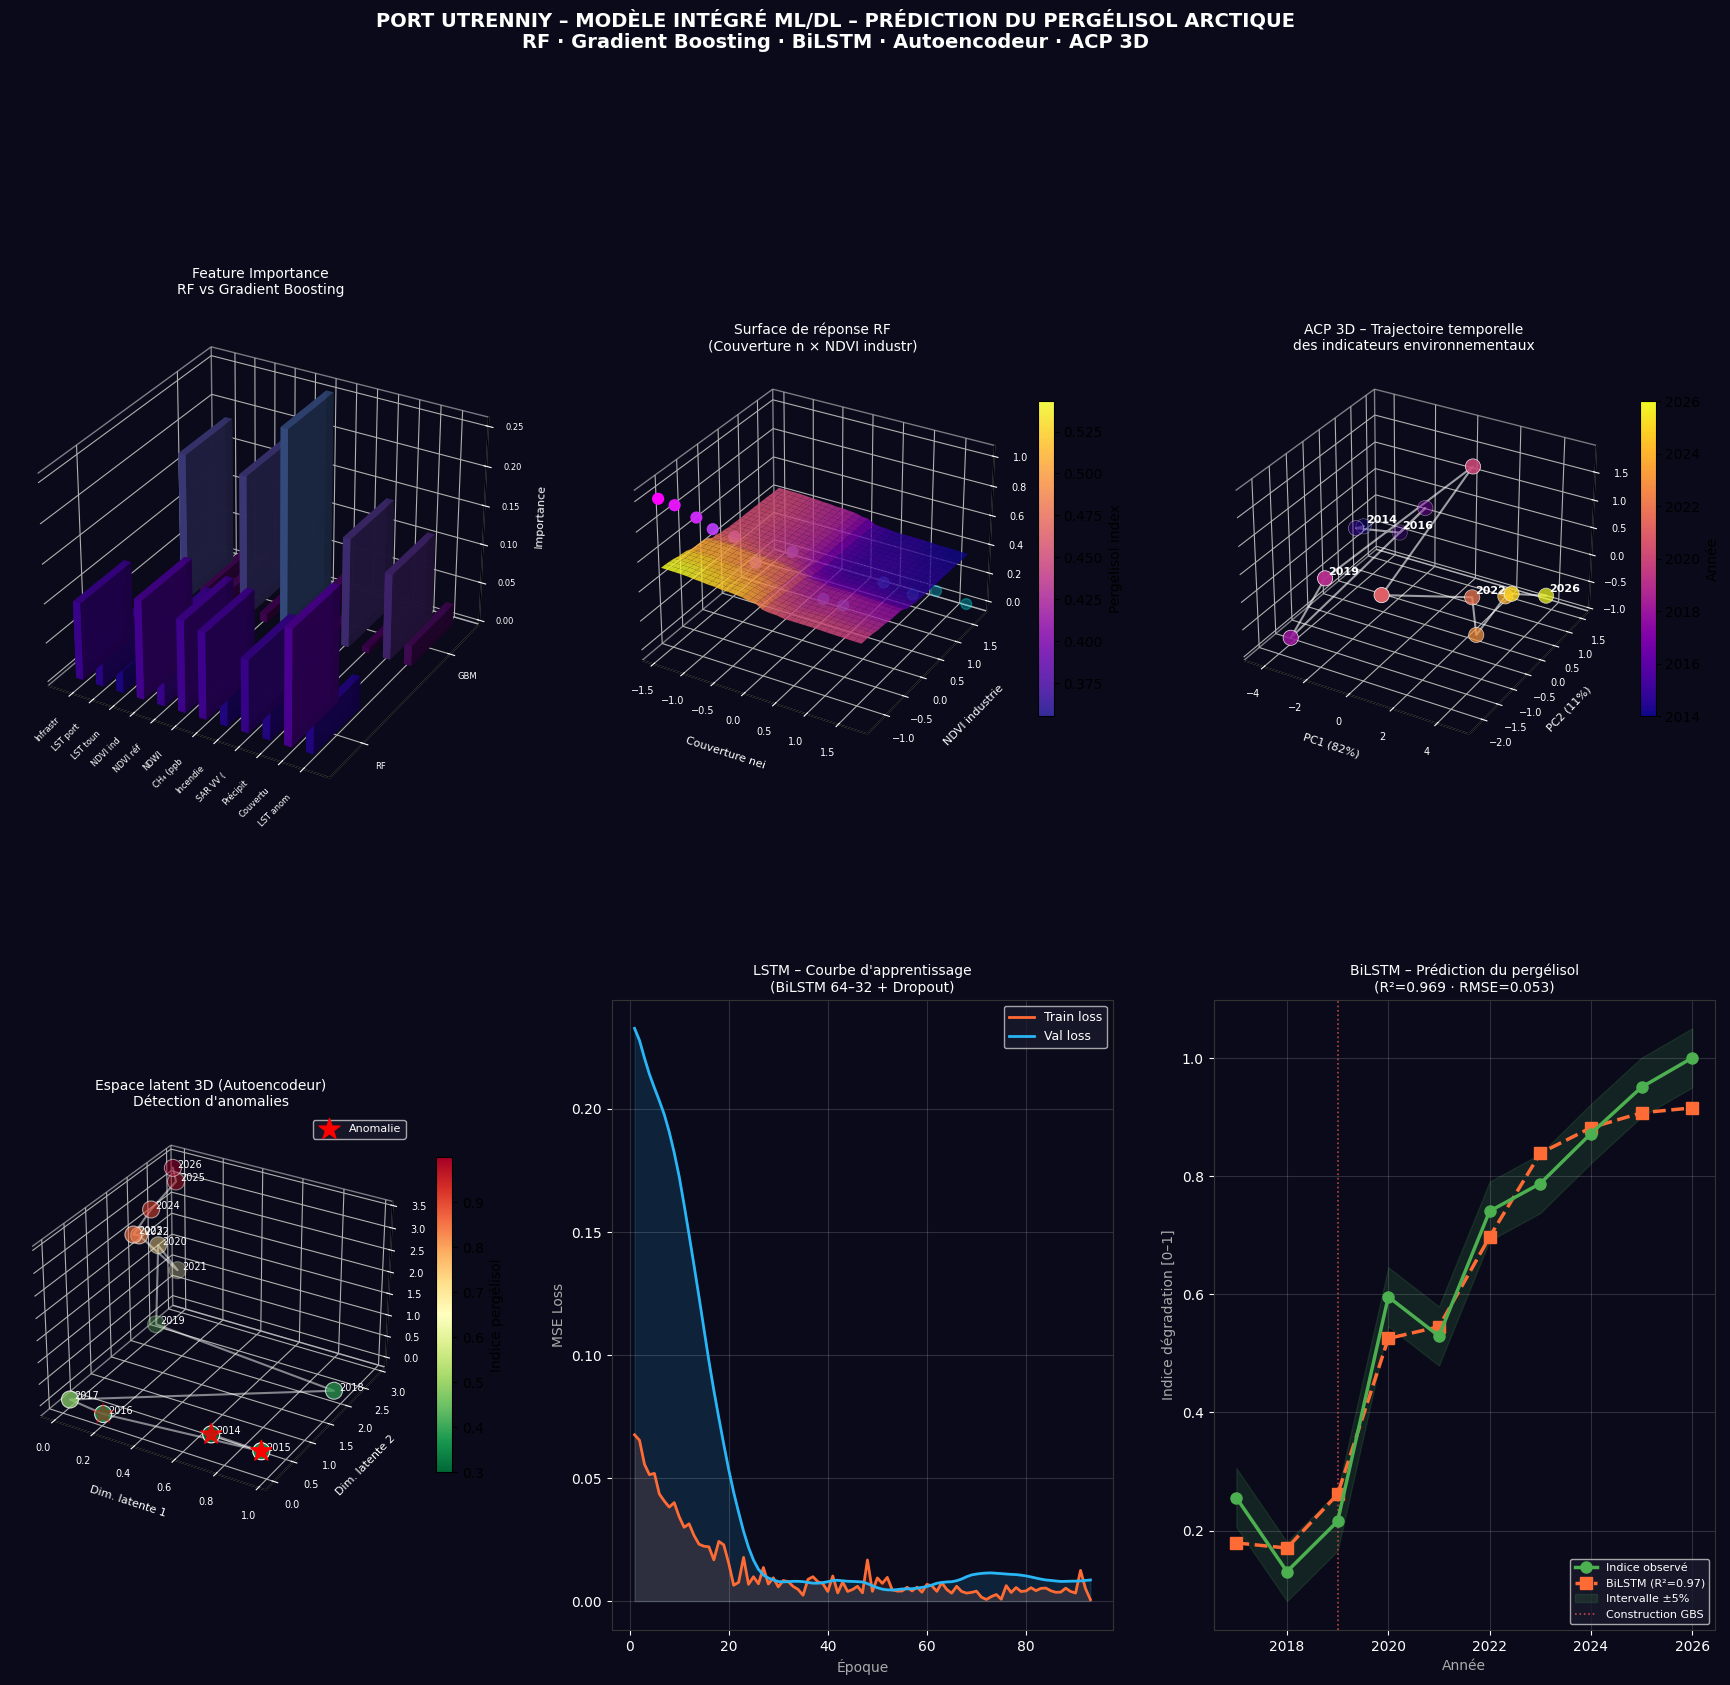

✓ Sauvegardé: ml_dl_permafrost_3d.png

────────────────────────────────────────────────────────────
VISUALISATIONS 3D INTERACTIVES – Plotly
────────────────────────────────────────────────────────────
   → Surface de réponse 3D interactive...


   ✓ Surface de réponse affichée
   → ACP 3D trajectoire temporelle...


   ✓ Trajectoire ACP 3D affichée
   → Espace latent autoencodeur...


   ✓ Espace latent autoencodeur affiché
   → Radar chart multi-indicateurs...


   ✓ Radar chart affiché

═════════════════════════════════════════════════════════════════
RÉCAPITULATIF DES PERFORMANCES MODÈLES
═════════════════════════════════════════════════════════════════
           Modèle R² (train)     R² (CV mean)                                   Rôle                Vis. 3D
    Random Forest      0.993 -15.661 ± 19.935 Feature importance, surface de réponse  ✓ Barres 3D + Surface
Gradient Boosting      1.000                –        Comparaison importance features            ✓ Barres 3D
           BiLSTM      0.969                –     Prédiction séquentielle temporelle ✓ Courbes + Prédiction

═════════════════════════════════════════════════════════════════
AUTOENCODEUR – ANOMALIES DÉTECTÉES
═════════════════════════════════════════════════════════════════
   2014 : score=0.2459 (seuil=0.1489)
   2015 : score=0.1702 (seuil=0.1489)
   2016 : score=0.1870 (seuil=0.1489)

═════════════════════════════════════════════════════════════════
TOP 5 FEATURES – IMPOR

In [2]:
!pip install tensorflow scikit-learn matplotlib plotly pandas numpy scipy -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings, json
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

BG = '#0A0A1A'

print("="*70)
print("PORT UTRENNIY – MODÈLE INTÉGRÉ ML/DL – PRÉDICTION PERGÉLISOL")
print("="*70)
print(f"TensorFlow {tf.__version__} · Scikit-learn OK\n")


print("─"*60)
print("ÉTAPE 1 : Construction du dataset multi-indicateurs")
print("─"*60)

years = np.array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026])
n     = len(years)


infra_ha   = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [0,0,93,200,350,500,650,780,923,948,955,953,958])

lst_port   = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [26.5,27.0,28.0,28.5,25.0,26.0,30.0,27.0,29.0,29.5,30.2,30.8,31.2])

lst_tundra = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [25.5,26.0,26.8,27.2,24.5,25.3,28.5,25.8,27.4,27.9,28.4,28.9,29.3])

ndvi_port  = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [0.32,0.31,0.28,0.25,0.22,0.20,0.17,0.15,0.13,0.12,0.11,0.10,0.09])

ndvi_ref   = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [0.38,0.39,0.38,0.37,0.36,0.37,0.35,0.36,0.34,0.33,0.33,0.32,0.31])

ndwi       = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [0.15,0.16,0.14,0.16,0.18,0.17,0.20,0.19,0.21,0.22,0.22,0.23,0.24])

ch4        = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [1810,1815,1820,1825,1830,1840,1850,1865,1880,1892,1898,1905,1912])

fire_count = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [2,3,1,4,5,8,12,9,7,6,8,10,9])

sar_vv     = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [-18,-18,-17,-16,-15,-13,-12,-11,-10,-10,-10,-10,-10])

precip     = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [280,260,275,290,255,270,300,285,310,295,305,290,315])

snow_cover = np.interp(years, [2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026],
                              [225,220,218,215,210,208,205,200,198,195,193,190,188])


lst_anom  = lst_port - lst_tundra
ndvi_loss = (ndvi_ref - ndvi_port) / ndvi_ref
water_idx = (ndwi - ndwi[0]) / (ndwi[0] + 1e-6)
permafrost_index = 0.4 * (lst_anom / lst_anom.max()) + \
                   0.4 * (ndvi_loss / ndvi_loss.max()) + \
                   0.2 * (water_idx / (water_idx.max() + 1e-6))

feature_names = ['Infrastructure (ha)', 'LST port (°C)', 'LST toundra (°C)',
                 'NDVI industriel', 'NDVI référence', 'NDWI', 'CH₄ (ppb)',
                 'Incendies (nb)', 'SAR VV (dB)', 'Précipitations (mm)',
                 'Couverture neige (j)', 'LST anomalie (ΔT)']

X_raw = np.column_stack([infra_ha, lst_port, lst_tundra, ndvi_port, ndvi_ref,
                         ndwi, ch4, fire_count, sar_vv, precip, snow_cover, lst_anom])
y_raw = permafrost_index


scaler_X = StandardScaler()
scaler_y = MinMaxScaler()
X = scaler_X.fit_transform(X_raw)
y = scaler_y.fit_transform(y_raw.reshape(-1,1)).ravel()

print(f"   ✓ Dataset : {X.shape[0]} observations × {X.shape[1]} features")
print(f"   ✓ Cible   : Indice de dégradation du pergélisol [0–1]")
print(f"   Features  : {', '.join(feature_names[:6])}")
print(f"              + {', '.join(feature_names[6:])}")


print("\n" + "─"*60)
print("ÉTAPE 2 : Random Forest – Feature Importance")
print("─"*60)

rf = RandomForestRegressor(n_estimators=500, max_depth=4, random_state=42,
                           min_samples_leaf=1, bootstrap=True)
rf.fit(X, y)

cv_scores = cross_val_score(rf, X, y, cv=min(5, len(X)//2), scoring='r2')
print(f"   ✓ R² cross-validation : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

importances = rf.feature_importances_
indices     = np.argsort(importances)[::-1]


gb = GradientBoostingRegressor(n_estimators=300, max_depth=3,
                               learning_rate=0.05, random_state=42)
gb.fit(X, y)
gb_imp = gb.feature_importances_

print(f"   ✓ Random Forest R² train : {r2_score(y, rf.predict(X)):.3f}")
print(f"   ✓ Gradient Boosting R²   : {r2_score(y, gb.predict(X)):.3f}")


print("\n" + "─"*60)
print("ÉTAPE 3 : LSTM – Modèle de prédiction temporelle du pergélisol")
print("─"*60)


WINDOW = 3

def make_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i:i+window])
        ys.append(y[i+window])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = make_sequences(X, y, WINDOW)
print(f"   Séquences : {X_seq.shape}  →  cibles : {y_seq.shape}")


inputs  = keras.Input(shape=(WINDOW, X.shape[1]))
x_lstm  = layers.Bidirectional(
    layers.LSTM(64, return_sequences=True, dropout=0.2))(inputs)
x_lstm  = layers.Bidirectional(
    layers.LSTM(32, return_sequences=False, dropout=0.2))(x_lstm)
x_dense = layers.Dense(32, activation='relu')(x_lstm)
x_dense = layers.Dropout(0.2)(x_dense)
x_dense = layers.Dense(16, activation='relu')(x_dense)
output  = layers.Dense(1, activation='sigmoid', name='permafrost_index')(x_dense)

lstm_model = keras.Model(inputs, output, name='BiLSTM_Permafrost')
lstm_model.compile(optimizer=keras.optimizers.Adam(1e-3),
                   loss='mse', metrics=['mae'])

print(f"   Architecture :")
lstm_model.summary()


history = lstm_model.fit(
    X_seq, y_seq,
    epochs=300, batch_size=4,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=40, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=20, min_lr=1e-5)
    ],
    verbose=0
)

y_pred_lstm = lstm_model.predict(X_seq, verbose=0).ravel()
r2_lstm = r2_score(y_seq, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_seq, y_pred_lstm))
print(f"\n   ✓ LSTM R²   : {r2_lstm:.3f}")
print(f"   ✓ LSTM RMSE : {rmse_lstm:.4f}")
epochs_ran = len(history.history['loss'])
print(f"   ✓ Entraîné sur {epochs_ran} époques")


print("\n" + "─"*60)
print("ÉTAPE 4 : Autoencodeur – Détection d'anomalies environnementales")
print("─"*60)

enc_input  = keras.Input(shape=(X.shape[1],), name='input')
encoded    = layers.Dense(8, activation='relu')(enc_input)
encoded    = layers.Dense(3, activation='relu', name='latent_space')(encoded)
decoded    = layers.Dense(8, activation='relu')(encoded)
decoded    = layers.Dense(X.shape[1], activation='linear', name='reconstruction')(decoded)

autoencoder = keras.Model(enc_input, decoded, name='Autoencoder_Anomaly')
encoder     = keras.Model(enc_input, autoencoder.get_layer('latent_space').output, name='Encoder')

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(X, X, epochs=500, batch_size=4,
                callbacks=[keras.callbacks.EarlyStopping(patience=50, restore_best_weights=True)],
                verbose=0)


X_recon = autoencoder.predict(X, verbose=0)
recon_error = np.mean((X - X_recon)**2, axis=1)
threshold   = np.percentile(recon_error, 75)
anomalies   = recon_error > threshold


latent = encoder.predict(X, verbose=0)
print(f"   ✓ Espace latent 3D : {latent.shape}")
print(f"   ✓ Années anomaliques : {list(years[anomalies])}")
print(f"   ✓ Seuil d'anomalie  : {threshold:.4f}")


pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)
explained = pca.explained_variance_ratio_
print(f"\n   ACP 3D – Variance expliquée : PC1={explained[0]*100:.1f}% · "
      f"PC2={explained[1]*100:.1f}% · PC3={explained[2]*100:.1f}%")
print(f"   Total : {sum(explained)*100:.1f}%")


print("\n" + "─"*60)
print("VISUALISATIONS 3D – Matplotlib")
print("─"*60)

fig3d = plt.figure(figsize=(22, 18), facecolor=BG)


ax_imp = fig3d.add_subplot(231, projection='3d')
ax_imp.set_facecolor(BG)

n_feat = len(feature_names)
xpos   = np.arange(n_feat)
ypos   = np.zeros(n_feat)
zpos   = np.zeros(n_feat)

cmap_imp = plt.cm.plasma
colors_imp_rf = [cmap_imp(v) for v in importances]
colors_imp_gb = [plt.cm.viridis(v) for v in gb_imp]

dx = 0.35
for i in range(n_feat):
    ax_imp.bar3d(xpos[i] - dx, 0, 0, dx, 0.5, importances[i],
                 color=colors_imp_rf[i], alpha=0.9, shade=True)
    ax_imp.bar3d(xpos[i],      1, 0, dx, 0.5, gb_imp[i],
                 color=colors_imp_gb[i], alpha=0.9, shade=True)

ax_imp.set_xticks(xpos)
ax_imp.set_xticklabels([f[:8] for f in feature_names], rotation=45,
                        ha='right', color='white', fontsize=6)
ax_imp.set_yticks([0.25, 1.25])
ax_imp.set_yticklabels(['RF', 'GBM'], color='white', fontsize=8)
ax_imp.set_zlabel('Importance', color='white', fontsize=8)
ax_imp.set_title('Feature Importance\nRF vs Gradient Boosting', color='white', fontsize=10, pad=10)
ax_imp.tick_params(colors='white', labelsize=6)
ax_imp.xaxis.pane.fill = False
ax_imp.yaxis.pane.fill = False
ax_imp.zaxis.pane.fill = False


ax_surf = fig3d.add_subplot(232, projection='3d')
ax_surf.set_facecolor(BG)


f1_idx, f2_idx = indices[0], indices[1]
f1_name = feature_names[f1_idx]
f2_name = feature_names[f2_idx]

n_grid = 30
f1_range = np.linspace(X[:, f1_idx].min(), X[:, f1_idx].max(), n_grid)
f2_range = np.linspace(X[:, f2_idx].min(), X[:, f2_idx].max(), n_grid)
F1, F2   = np.meshgrid(f1_range, f2_range)


X_grid = np.tile(X.mean(axis=0), (n_grid*n_grid, 1))
X_grid[:, f1_idx] = F1.ravel()
X_grid[:, f2_idx] = F2.ravel()
Z = rf.predict(X_grid).reshape(n_grid, n_grid)

surf = ax_surf.plot_surface(F1, F2, Z, cmap='plasma', alpha=0.85,
                            linewidth=0, antialiased=True)

ax_surf.scatter(X[:, f1_idx], X[:, f2_idx], y,
                c=years, cmap='cool', s=60, zorder=5, depthshade=True)

ax_surf.set_xlabel(f1_name[:14], color='white', fontsize=8, labelpad=8)
ax_surf.set_ylabel(f2_name[:14], color='white', fontsize=8, labelpad=8)
ax_surf.set_zlabel('Indice pergélisol', color='white', fontsize=8)
ax_surf.set_title(f'Surface de réponse RF\n({f1_name[:12]} × {f2_name[:12]})',
                  color='white', fontsize=10)
ax_surf.tick_params(colors='white', labelsize=7)
ax_surf.xaxis.pane.fill = False
ax_surf.yaxis.pane.fill = False
ax_surf.zaxis.pane.fill = False
plt.colorbar(surf, ax=ax_surf, shrink=0.5, label='Pergélisol index')


ax_pca = fig3d.add_subplot(233, projection='3d')
ax_pca.set_facecolor(BG)

scatter_pca = ax_pca.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                              c=years, cmap='plasma', s=120,
                              zorder=5, depthshade=True,
                              edgecolors='white', linewidth=0.5)

ax_pca.plot(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
            '-', color='white', lw=1.5, alpha=0.6)


for i, yr in enumerate(years):
    if yr in [2014, 2016, 2019, 2022, 2026]:
        ax_pca.text(X_pca[i,0]+0.05, X_pca[i,1]+0.05, X_pca[i,2]+0.05,
                    str(yr), color='white', fontsize=8, fontweight='bold')

ax_pca.set_xlabel(f'PC1 ({explained[0]*100:.0f}%)', color='white', fontsize=8)
ax_pca.set_ylabel(f'PC2 ({explained[1]*100:.0f}%)', color='white', fontsize=8)
ax_pca.set_zlabel(f'PC3 ({explained[2]*100:.0f}%)', color='white', fontsize=8)
ax_pca.set_title('ACP 3D – Trajectoire temporelle\ndes indicateurs environnementaux',
                 color='white', fontsize=10)
ax_pca.tick_params(colors='white', labelsize=7)
ax_pca.xaxis.pane.fill = False
ax_pca.yaxis.pane.fill = False
ax_pca.zaxis.pane.fill = False
plt.colorbar(scatter_pca, ax=ax_pca, shrink=0.5, label='Année')


ax_latent = fig3d.add_subplot(234, projection='3d')
ax_latent.set_facecolor(BG)

scatter_lat = ax_latent.scatter(
    latent[:, 0], latent[:, 1], latent[:, 2],
    c=permafrost_index, cmap='RdYlGn_r', s=150,
    zorder=5, depthshade=True, edgecolors='white', linewidth=0.8
)
ax_latent.plot(latent[:, 0], latent[:, 1], latent[:, 2],
               '-', color='white', lw=1.5, alpha=0.5)


anom_idx = np.where(anomalies)[0]
ax_latent.scatter(latent[anom_idx, 0], latent[anom_idx, 1], latent[anom_idx, 2],
                  color='red', s=250, marker='*', zorder=10, label='Anomalie')

for i, yr in enumerate(years):
    ax_latent.text(latent[i,0]+0.02, latent[i,1]+0.02, latent[i,2]+0.02,
                   str(yr), color='white', fontsize=7)

ax_latent.set_xlabel('Dim. latente 1', color='white', fontsize=8)
ax_latent.set_ylabel('Dim. latente 2', color='white', fontsize=8)
ax_latent.set_zlabel('Dim. latente 3', color='white', fontsize=8)
ax_latent.set_title('Espace latent 3D (Autoencodeur)\nDétection d\'anomalies',
                    color='white', fontsize=10)
ax_latent.tick_params(colors='white', labelsize=7)
ax_latent.legend(fontsize=8, facecolor='#1A1A2E', labelcolor='white')
ax_latent.xaxis.pane.fill = False
ax_latent.yaxis.pane.fill = False
ax_latent.zaxis.pane.fill = False
plt.colorbar(scatter_lat, ax=ax_latent, shrink=0.5, label='Indice pergélisol')


ax_hist = fig3d.add_subplot(235)
ax_hist.set_facecolor(BG)

epochs_x = range(1, epochs_ran + 1)
ax_hist.plot(epochs_x, history.history['loss'], color='#FF6B35', lw=2, label='Train loss')
ax_hist.plot(epochs_x, history.history['val_loss'], color='#29B6F6', lw=2, label='Val loss')
ax_hist.fill_between(epochs_x, history.history['loss'], alpha=0.15, color='#FF6B35')
ax_hist.fill_between(epochs_x, history.history['val_loss'], alpha=0.15, color='#29B6F6')
ax_hist.set_title('LSTM – Courbe d\'apprentissage\n(BiLSTM 64–32 + Dropout)',
                  color='white', fontsize=10)
ax_hist.set_xlabel('Époque', color='#AAA')
ax_hist.set_ylabel('MSE Loss', color='#AAA')
ax_hist.legend(facecolor='#1A1A2E', labelcolor='white', fontsize=9)
ax_hist.tick_params(colors='white')
ax_hist.spines[:].set_color('#333')
ax_hist.grid(alpha=0.15, color='white')


ax_pred = fig3d.add_subplot(236)
ax_pred.set_facecolor(BG)

years_lstm = years[WINDOW:]
ax_pred.plot(years_lstm, y_seq,       'o-', color='#4CAF50', lw=2.5, ms=8,
             label='Indice observé', zorder=5)
ax_pred.plot(years_lstm, y_pred_lstm, 's--', color='#FF6B35', lw=2.5, ms=8,
             label=f'BiLSTM (R²={r2_lstm:.2f})', zorder=4)
ax_pred.fill_between(years_lstm,
                     y_seq - 0.05, y_seq + 0.05,
                     alpha=0.15, color='#4CAF50', label='Intervalle ±5%')
ax_pred.axvline(2019, color='#EF5350', lw=1.2, ls=':', alpha=0.8, label='Construction GBS')
ax_pred.set_title(f'BiLSTM – Prédiction du pergélisol\n(R²={r2_lstm:.3f} · RMSE={rmse_lstm:.3f})',
                  color='white', fontsize=10)
ax_pred.set_xlabel('Année', color='#AAA')
ax_pred.set_ylabel('Indice dégradation [0–1]', color='#AAA')
ax_pred.legend(facecolor='#1A1A2E', labelcolor='white', fontsize=8)
ax_pred.tick_params(colors='white')
ax_pred.spines[:].set_color('#333')
ax_pred.grid(alpha=0.15, color='white')

plt.suptitle('PORT UTRENNIY – MODÈLE INTÉGRÉ ML/DL – PRÉDICTION DU PERGÉLISOL ARCTIQUE\n'
             'RF · Gradient Boosting · BiLSTM · Autoencodeur · ACP 3D',
             color='white', fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig('/content/ml_dl_permafrost_3d.png', dpi=200, bbox_inches='tight', facecolor=BG)
plt.show()
print("✓ Sauvegardé: ml_dl_permafrost_3d.png")


print("\n" + "─"*60)
print("VISUALISATIONS 3D INTERACTIVES – Plotly")
print("─"*60)


print("   → Surface de réponse 3D interactive...")

fig_surf = go.Figure()

fig_surf.add_trace(go.Surface(
    x=F1, y=F2, z=Z,
    colorscale='Plasma',
    opacity=0.85,
    name='Surface RF',
    colorbar=dict(title='Indice pergélisol', titlefont=dict(color='white'),
                  tickfont=dict(color='white'))
))

fig_surf.add_trace(go.Scatter3d(
    x=X[:, f1_idx], y=X[:, f2_idx], z=y,
    mode='markers+text',
    marker=dict(size=8, color=years, colorscale='Viridis',
                showscale=True, colorbar=dict(title='Année', x=1.1,
                titlefont=dict(color='white'), tickfont=dict(color='white')),
                line=dict(color='white', width=1)),
    text=[str(yr) for yr in years],
    textposition='top center',
    textfont=dict(color='white', size=10),
    name='Observations',
))

fig_surf.update_layout(
    title=dict(text=f'<b>Surface de réponse RF</b><br>'
                    f'<sup>{f1_name} × {f2_name} → Indice dégradation pergélisol</sup>',
               font=dict(color='white', size=16), x=0.5),
    scene=dict(
        xaxis=dict(title=f1_name[:14], gridcolor='#333', backgroundcolor='#0A0A1A',
                   color='white'),
        yaxis=dict(title=f2_name[:14], gridcolor='#333', backgroundcolor='#0A0A1A',
                   color='white'),
        zaxis=dict(title='Indice pergélisol', gridcolor='#333', backgroundcolor='#0A0A1A',
                   color='white'),
        bgcolor='#0A0A1A',
        camera=dict(eye=dict(x=1.4, y=1.4, z=1.0))
    ),
    paper_bgcolor='#0A0A1A',
    plot_bgcolor='#0A0A1A',
    font=dict(color='white'),
    width=900, height=700,
)
fig_surf.show()
print("   ✓ Surface de réponse affichée")


print("   → ACP 3D trajectoire temporelle...")

fig_pca = go.Figure()


fig_pca.add_trace(go.Scatter3d(
    x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2],
    mode='lines',
    line=dict(color='rgba(255,255,255,0.4)', width=3),
    name='Trajectoire temporelle'
))


fig_pca.add_trace(go.Scatter3d(
    x=X_pca[:, 0], y=X_pca[:, 1], z=X_pca[:, 2],
    mode='markers+text',
    marker=dict(
        size=12,
        color=permafrost_index,
        colorscale='RdYlGn_r',
        showscale=True,
        colorbar=dict(title='Indice dégradation', titlefont=dict(color='white'),
                      tickfont=dict(color='white')),
        line=dict(color='white', width=1)
    ),
    text=[str(yr) for yr in years],
    textposition='top center',
    textfont=dict(color='white', size=11),
    name='Année',
))


for idx in anom_idx:
    fig_pca.add_trace(go.Scatter3d(
        x=[X_pca[idx, 0]], y=[X_pca[idx, 1]], z=[X_pca[idx, 2]],
        mode='markers',
        marker=dict(size=18, color='red', symbol='diamond',
                    line=dict(color='white', width=2)),
        name=f'Anomalie {years[idx]}',
        showlegend=True
    ))

fig_pca.update_layout(
    title=dict(text='<b>ACP 3D – Trajectoire temporelle des indicateurs environnementaux</b><br>'
                    f'<sup>Port Utrenniy 2014–2026 · {sum(explained)*100:.0f}% de variance expliquée</sup>',
               font=dict(color='white', size=15), x=0.5),
    scene=dict(
        xaxis=dict(title=f'PC1 ({explained[0]*100:.0f}%)', gridcolor='#333',
                   backgroundcolor='#0A0A1A', color='white'),
        yaxis=dict(title=f'PC2 ({explained[1]*100:.0f}%)', gridcolor='#333',
                   backgroundcolor='#0A0A1A', color='white'),
        zaxis=dict(title=f'PC3 ({explained[2]*100:.0f}%)', gridcolor='#333',
                   backgroundcolor='#0A0A1A', color='white'),
        bgcolor='#0A0A1A',
        camera=dict(eye=dict(x=1.5, y=1.2, z=0.8))
    ),
    paper_bgcolor='#0A0A1A', plot_bgcolor='#0A0A1A',
    font=dict(color='white'),
    width=950, height=720,
)
fig_pca.show()
print("   ✓ Trajectoire ACP 3D affichée")


print("   → Espace latent autoencodeur...")

fig_latent = go.Figure()


fig_latent.add_trace(go.Scatter3d(
    x=latent[:, 0], y=latent[:, 1], z=latent[:, 2],
    mode='lines',
    line=dict(color='rgba(150,150,255,0.3)', width=2),
    name='Trajectoire'
))


normal_mask = ~anomalies
fig_latent.add_trace(go.Scatter3d(
    x=latent[normal_mask, 0], y=latent[normal_mask, 1], z=latent[normal_mask, 2],
    mode='markers+text',
    marker=dict(size=10, color=permafrost_index[normal_mask],
                colorscale='Viridis', showscale=True,
                colorbar=dict(title='Indice pergélisol', titlefont=dict(color='white'),
                              tickfont=dict(color='white'), x=1.05),
                line=dict(color='white', width=1)),
    text=[str(yr) for yr in years[normal_mask]],
    textfont=dict(color='white', size=10),
    textposition='top center',
    name='Année (normal)'
))


if len(anom_idx) > 0:
    fig_latent.add_trace(go.Scatter3d(
        x=latent[anom_idx, 0], y=latent[anom_idx, 1], z=latent[anom_idx, 2],
        mode='markers+text',
        marker=dict(size=16, color='red', symbol='diamond',
                    line=dict(color='white', width=2)),
        text=[f'⚠ {years[i]}' for i in anom_idx],
        textfont=dict(color='red', size=11, family='bold'),
        textposition='top center',
        name='Anomalie détectée'
    ))


pre  = latent[years < 2019]
post = latent[years >= 2019]
fig_latent.add_trace(go.Mesh3d(
    x=pre[:, 0], y=pre[:, 1], z=pre[:, 2],
    opacity=0.12, color='#4CAF50', name='Régime pré-2019',
    alphahull=0
))
fig_latent.add_trace(go.Mesh3d(
    x=post[:, 0], y=post[:, 1], z=post[:, 2],
    opacity=0.12, color='#FF5722', name='Régime post-2019',
    alphahull=0
))

fig_latent.update_layout(
    title=dict(
        text='<b>Espace latent 3D – Autoencodeur</b><br>'
             '<sup>Détection d\'anomalies environnementales · Port Utrenniy 2014–2026</sup>',
        font=dict(color='white', size=15), x=0.5),
    scene=dict(
        xaxis=dict(title='Dim. latente 1', gridcolor='#333',
                   backgroundcolor='#0A0A1A', color='white'),
        yaxis=dict(title='Dim. latente 2', gridcolor='#333',
                   backgroundcolor='#0A0A1A', color='white'),
        zaxis=dict(title='Dim. latente 3', gridcolor='#333',
                   backgroundcolor='#0A0A1A', color='white'),
        bgcolor='#0A0A1A',
        camera=dict(eye=dict(x=1.5, y=1.3, z=0.9))
    ),
    paper_bgcolor='#0A0A1A', plot_bgcolor='#0A0A1A',
    font=dict(color='white'),
    width=950, height=730,
)
fig_latent.show()
print("   ✓ Espace latent autoencodeur affiché")


print("   → Radar chart multi-indicateurs...")

def zscore_arr(arr):
    arr = np.array(arr, dtype=float)
    return (arr - arr.mean()) / (arr.std() + 1e-9)

features_radar = ['Infrastructure', 'LST Port', 'LST Toundra', 'NDVI Port',
                  'NDWI', 'CH₄', 'Incendies', 'SAR VV']
X_radar_raw = np.column_stack([infra_ha, lst_port, lst_tundra, ndvi_port,
                                ndwi, ch4, fire_count, sar_vv])
X_radar_z   = np.column_stack([zscore_arr(X_radar_raw[:, i])
                                for i in range(X_radar_raw.shape[1])])

X_radar_01  = (X_radar_z - X_radar_z.min(axis=0)) / \
               (X_radar_z.max(axis=0) - X_radar_z.min(axis=0) + 1e-9)

highlight_years = [2014, 2016, 2019, 2022, 2026]
colors_radar    = ['#4CAF50', '#29B6F6', '#FF9800', '#EF5350', '#E040FB']

fig_radar = go.Figure()
for yr, col in zip(highlight_years, colors_radar):
    idx_yr = list(years).index(yr)
    vals = list(X_radar_01[idx_yr]) + [X_radar_01[idx_yr, 0]]
    cats = features_radar + [features_radar[0]]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals, theta=cats,
        fill='toself', fillcolor=col,
        opacity=0.20,
        line=dict(color=col, width=2),
        name=str(yr)
    ))

fig_radar.update_layout(
    polar=dict(
        bgcolor='#0A0A1A',
        radialaxis=dict(visible=True, range=[0,1], color='white',
                        gridcolor='#333', tickfont=dict(color='white')),
        angularaxis=dict(color='white', gridcolor='#333',
                         tickfont=dict(color='white', size=11))
    ),
    title=dict(text='<b>Profils multi-indicateurs par année</b><br>'
                    '<sup>Port Utrenniy – Évolution des signatures environnementales 2014–2026</sup>',
               font=dict(color='white', size=15), x=0.5),
    paper_bgcolor='#0A0A1A',
    font=dict(color='white'),
    legend=dict(font=dict(color='white'), bgcolor='#1A1A2E'),
    width=800, height=700
)
fig_radar.show()
print("   ✓ Radar chart affiché")


print("\n" + "═"*65)
print("RÉCAPITULATIF DES PERFORMANCES MODÈLES")
print("═"*65)

results_summary = pd.DataFrame({
    'Modèle': ['Random Forest', 'Gradient Boosting', 'BiLSTM'],
    'R² (train)': [f"{r2_score(y, rf.predict(X)):.3f}",
                   f"{r2_score(y, gb.predict(X)):.3f}",
                   f"{r2_lstm:.3f}"],
    'R² (CV mean)': [f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}", "–", "–"],
    'Rôle': ['Feature importance, surface de réponse',
             'Comparaison importance features',
             'Prédiction séquentielle temporelle'],
    'Vis. 3D': ['✓ Barres 3D + Surface', '✓ Barres 3D', '✓ Courbes + Prédiction']
})
print(results_summary.to_string(index=False))

print("\n" + "═"*65)
print("AUTOENCODEUR – ANOMALIES DÉTECTÉES")
print("═"*65)
for i in anom_idx:
    print(f"   {years[i]} : score={recon_error[i]:.4f} (seuil={threshold:.4f})")

print("\n" + "═"*65)
print("TOP 5 FEATURES – IMPORTANCE POUR LE PERGÉLISOL")
print("═"*65)
for rank, i in enumerate(indices[:5], 1):
    print(f"   {rank}. {feature_names[i]:30s} RF={importances[i]:.3f}  GBM={gb_imp[i]:.3f}")

print("\n✓ Section ML/DL complète — figures exportées dans /content/")
